In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor


from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("/content/Fraud.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [6]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df.shape

(6362620, 11)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [12]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [13]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [14]:
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [15]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
)

In [16]:
df["dest_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
)

In [17]:
df["is_merchant"] = df["nameDest"].str.startswith("M").astype(int)

In [18]:
df["hour"] = df["step"] % 24

In [19]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)


In [20]:
df.drop(["nameOrig", "nameDest"], axis=1, inplace=True)


In [21]:
num_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]

for col in num_cols:
    upper = df[col].quantile(0.999)
    df[col] = np.where(df[col] > upper, upper, df[col])


In [24]:
def calculate_vif_safe(df):  # Keep only numeric columns
    df_numeric = df.select_dtypes(include=[np.number])
    df_numeric = df_numeric.astype(np.float64)

    vif_df = pd.DataFrame()
    vif_df["feature"] = df_numeric.columns
    vif_df["VIF"] = [
        variance_inflation_factor(df_numeric.values, i)
        for i in range(df_numeric.shape[1])
    ]
    return vif_df

In [25]:
X_vif = df.drop("isFraud", axis=1)
calculate_vif_safe(X_vif).sort_values("VIF", ascending=False).head(10)


,feature,VIF
8,dest_balance_change,inf
9,orig_balance_error,inf
10,dest_balance_error,inf
7,orig_balance_change,inf
3,newbalanceOrig,3.151505e+04
2,oldbalanceOrg,3.068569e+04
5,newbalanceDest,2.091287e+02
4,oldbalanceDest,1.825653e+02
1,amount,1.224820e+01
12,hour,4.198081e+00


In [26]:
train_df = df[df["step"] <= 600]   # ~25 days
val_df   = df[df["step"] > 600]    # ~5 days

X_train = train_df.drop("isFraud", axis=1)
y_train = train_df["isFraud"]

X_val = val_df.drop("isFraud", axis=1)
y_val = val_df["isFraud"]

print("Training fraud rate:", y_train.mean())


Training fraud rate: 0.0010565506218438686


In [27]:
smote = SMOTE(sampling_strategy=0.05, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE fraud rate:", y_train_sm.mean())


After SMOTE fraud rate: 0.04761894607128196


In [28]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train_sm, y_train_sm)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101973
           1       0.99      1.00      1.00      1600

    accuracy                           1.00    103573
   macro avg       1.00      1.00      1.00    103573
weighted avg       1.00      1.00      1.00    103573

ROC-AUC: 0.9999984493444344


In [31]:
pd.Series(y_prob).describe()



,0
count,1.035730e+05
mean,1.548495e-02
std,1.229828e-01
min,2.259728e-07
25%,8.585791e-07
50%,2.399862e-06
75%,1.081739e-05
max,9.999869e-01


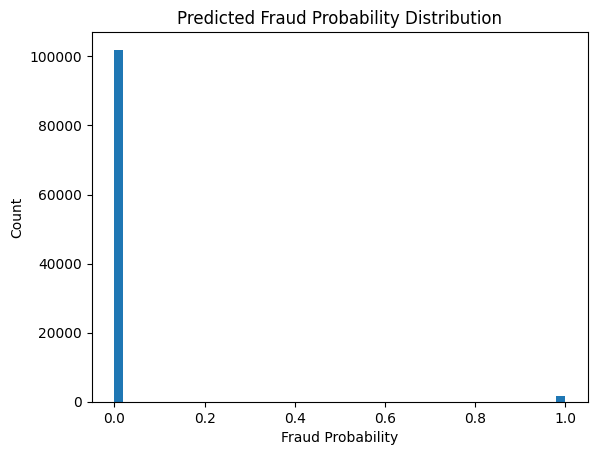

In [32]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=50)
plt.title("Predicted Fraud Probability Distribution")
plt.xlabel("Fraud Probability")
plt.ylabel("Count")
plt.show()


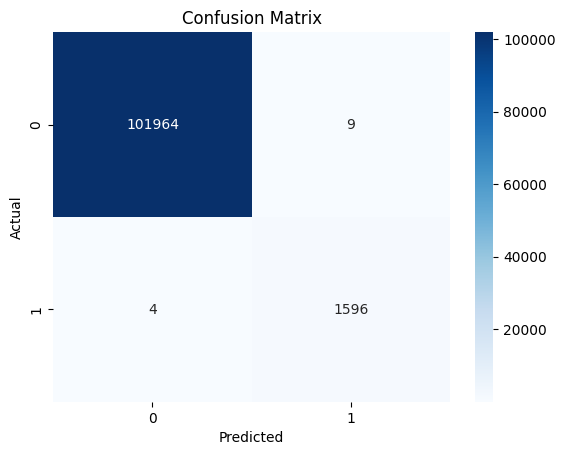

In [33]:
cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


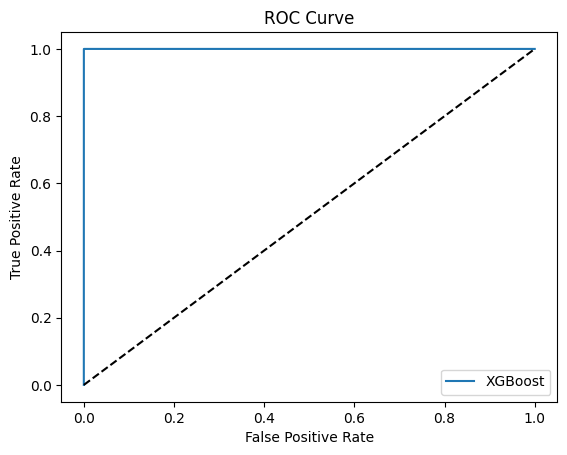

In [34]:
fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [35]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)


,feature,importance
7,orig_balance_change,0.256923
3,newbalanceOrig,0.249493
15,type_PAYMENT,0.188588
9,orig_balance_error,0.112221
11,is_merchant,0.092914
8,dest_balance_change,0.014734
16,type_TRANSFER,0.014713
14,type_DEBIT,0.013120
1,amount,0.012247
12,hour,0.011769


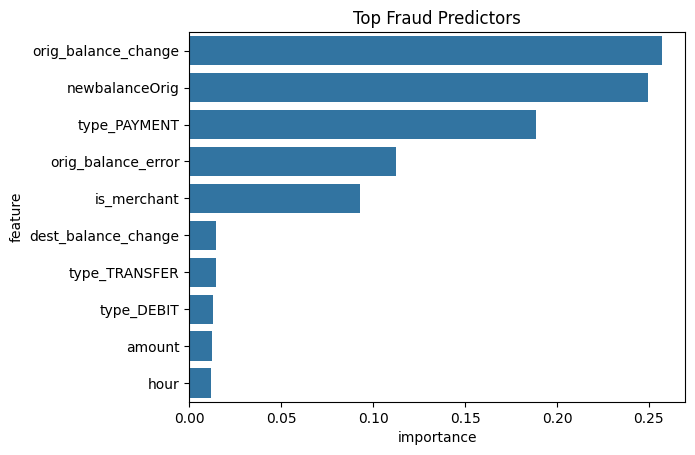

In [36]:
sns.barplot(
    x="importance",
    y="feature",
    data=importance.head(10)
)
plt.title("Top Fraud Predictors")
plt.show()
